In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
sys.path.append("..")  # Trỏ về thư mục cha (StrokePrediction) để tìm gói 'src'

import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

from src.preprocessing import load_data, split_data, get_preprocessor, RANDOM_STATE
from src.models import get_models

print("Đang chạy Cross-Validation...")

# 1. Load và chia dữ liệu
df = load_data()
X_train, X_test, y_train, y_test = split_data(df)

# 2. Thiết lập 5-Fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["recall", "precision", "f1", "roc_auc"]

rows = []
# 3. Đánh giá từng mô hình
for name, model in get_models().items():
    pipe = ImbPipeline([
        ("preprocessor", get_preprocessor()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", model)
    ])
    
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    
    row = {"Model": name}
    for m in scoring:
        row[f"{m}_mean"] = res[f"test_{m}"].mean()
        row[f"{m}_std"] = res[f"test_{m}"].std()
    rows.append(row)
    print(f" -> Hoàn tất mô hình: {name}")

# 4. Xuất bảng kết quả ra file
cv_results = pd.DataFrame(rows).sort_values(by="recall_mean", ascending=False).round(3)
cv_results.to_csv("../results/cv_results.csv", index=False)

print("\n=== XUẤT KẾT QUẢ THÀNH CÔNG ===")
display(cv_results)

Đang chạy Cross-Validation...
 -> Hoàn tất mô hình: Logistic Regression
 -> Hoàn tất mô hình: Decision Tree
 -> Hoàn tất mô hình: KNN
 -> Hoàn tất mô hình: SVM
 -> Hoàn tất mô hình: Random Forest
 -> Hoàn tất mô hình: XGBoost

=== XUẤT KẾT QUẢ THÀNH CÔNG ===


,Model,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.779,0.039,0.140,0.010,0.237,0.015,0.848,0.010
3,SVM,0.483,0.082,0.122,0.016,0.194,0.025,0.787,0.025
2,KNN,0.412,0.054,0.127,0.011,0.194,0.018,0.684,0.039
1,Decision Tree,0.221,0.018,0.143,0.021,0.173,0.020,0.576,0.011
4,Random Forest,0.121,0.009,0.202,0.021,0.150,0.010,0.803,0.016
5,XGBoost,0.110,0.060,0.187,0.114,0.138,0.078,0.801,0.018


In [3]:
import joblib
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from src.preprocessing import load_data, split_data, get_preprocessor, RANDOM_STATE
from src.models import get_models

print("1. Đang tải dữ liệu...")
df = load_data()
X_train, X_test, y_train, y_test = split_data(df)

# 2. Tạo Pipeline cơ sở với Random Forest
pipe = ImbPipeline([
    ("preprocessor", get_preprocessor()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", get_models()["Random Forest"])
])

# 3. Lưới tham số cần tinh chỉnh cho Random Forest
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__criterion": ["gini", "entropy"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("2. Đang chạy GridSearchCV tìm bộ tham số tối ưu (tối ưu Recall)...")
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n=== KẾT QUẢ TUNING ===")
print(f"Tham số tốt nhất: {grid_search.best_params_}")
print(f"Recall Cross-Validation tốt nhất: {grid_search.best_score_:.3f}")

# 4. Đánh giá mô hình đã tune trên tập Test độc lập
best_pipeline = grid_search.best_estimator_
y_pred = best_pipeline.predict(X_test)

# 5. Lưu mô hình hoàn chỉnh vào thư mục models/
joblib.dump(best_pipeline, "../models/stroke_pipeline.pkl")
print("\n=== ĐÃ LƯU MÔ HÌNH HOÀN CHỈNH VÀO models/stroke_pipeline.pkl ===")

1. Đang tải dữ liệu...
2. Đang chạy GridSearchCV tìm bộ tham số tối ưu (tối ưu Recall)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

=== KẾT QUẢ TUNING ===
Tham số tốt nhất: {'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Recall Cross-Validation tốt nhất: 0.297

=== ĐÃ LƯU MÔ HÌNH HOÀN CHỈNH VÀO models/stroke_pipeline.pkl ===


In [4]:
import sys
sys.path.append("..") # Trỏ về thư mục gốc StrokePrediction

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.tree import plot_tree
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from src.preprocessing import load_data, split_data, get_preprocessor, RANDOM_STATE
from src.models import get_models

print("=== ĐÃ IMPORT THÀNH CÔNG DỮ LIỆU VÀ THƯ VIỆN ===")

=== ĐÃ IMPORT THÀNH CÔNG DỮ LIỆU VÀ THƯ VIỆN ===


In [5]:
print("============================================================")
print("              1. TẢI VÀ CHUẨN BỊ DỮ LIỆU DỰ ÁN")
print("============================================================")

df = load_data()
X_train, X_test, y_train, y_test = split_data(df)

preprocessor = get_preprocessor()
preprocessor.fit(X_train)

# Fit & transform preprocessor + SMOTE trên tập Train
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)

# Lấy danh sách tên cột an toàn (không bị lỗi phiên bản scikit-learn)
try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    try:
        feature_names = preprocessor.get_feature_names_out(X_train.columns)
    except Exception:
        feature_names = [f"Feature_{i}" for i in range(X_train_prep.shape[1])]

print("Kích thước X_train ban đầu:", X_train.shape)
print("Kích thước X_train sau SMOTE:", X_train_res.shape)
print("Phân bố y_train sau SMOTE:\n", pd.Series(y_train_res).value_counts())

              1. TẢI VÀ CHUẨN BỊ DỮ LIỆU DỰ ÁN
Kích thước X_train ban đầu: (4088, 10)
Kích thước X_train sau SMOTE: (7778, 22)
Phân bố y_train sau SMOTE:
 stroke
0    3889
1    3889
Name: count, dtype: int64


In [6]:
print("============================================================")
print("           2. HUẤN LUYỆN VÀ ĐÁNH GIÁ 6 MÔ HÌNH")
print("============================================================")

models = get_models(random_state=RANDOM_STATE)
predictions = {}
probabilities = {}
trained_models = {}

for name, model in models.items():
    print(f"\n---> Đang huấn luyện: {name}...")
    model.fit(X_train_res, y_train_res)
    
    y_pred = model.predict(X_test_prep)
    predictions[name] = y_pred
    trained_models[name] = model
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_prep)[:, 1]
    else:
        y_prob = model.decision_function(X_test_prep)
    probabilities[name] = y_prob
    
    print(f"Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")
    print(f"Recall   : {recall_score(y_test, y_pred)*100:.2f}%")
    print(f"Precision: {precision_score(y_test, y_pred)*100:.2f}%")
    print(f"F1-score : {f1_score(y_test, y_pred)*100:.2f}%")
    print("Báo cáo phân loại:\n", classification_report(y_test, y_pred, target_names=["Bình thường", "Bị đột quỵ"]))

           2. HUẤN LUYỆN VÀ ĐÁNH GIÁ 6 MÔ HÌNH

---> Đang huấn luyện: Logistic Regression...
Accuracy : 75.93%
Recall   : 78.00%
Precision: 14.23%
F1-score : 24.07%
Báo cáo phân loại:
               precision    recall  f1-score   support

 Bình thường       0.99      0.76      0.86       972
  Bị đột quỵ       0.14      0.78      0.24        50

    accuracy                           0.76      1022
   macro avg       0.56      0.77      0.55      1022
weighted avg       0.94      0.76      0.83      1022


---> Đang huấn luyện: Decision Tree...
Accuracy : 88.85%
Recall   : 16.00%
Precision: 10.00%
F1-score : 12.31%
Báo cáo phân loại:
               precision    recall  f1-score   support

 Bình thường       0.96      0.93      0.94       972
  Bị đột quỵ       0.10      0.16      0.12        50

    accuracy                           0.89      1022
   macro avg       0.53      0.54      0.53      1022
weighted avg       0.91      0.89      0.90      1022


---> Đang huấn luyện: KNN...

       3. TRỰC QUAN HÓA CẤU TRÚC VÀ ĐẶC TRƯNG QUAN TRỌNG


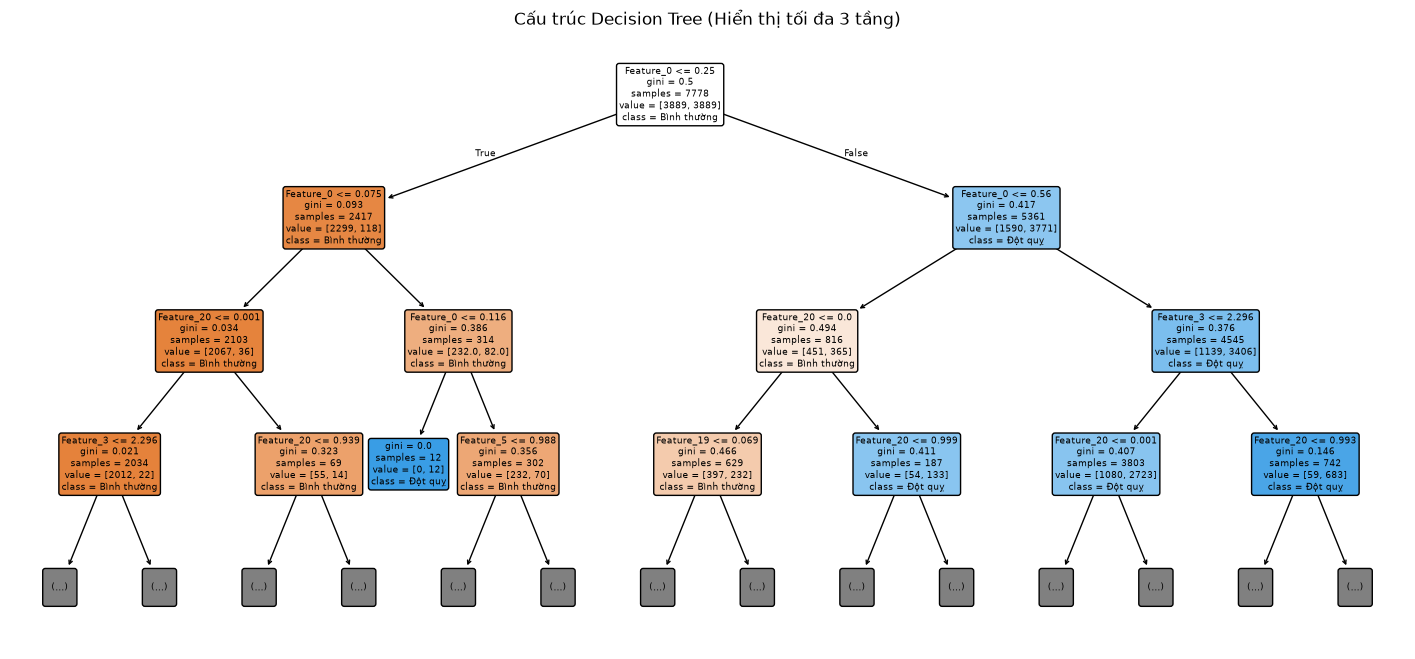

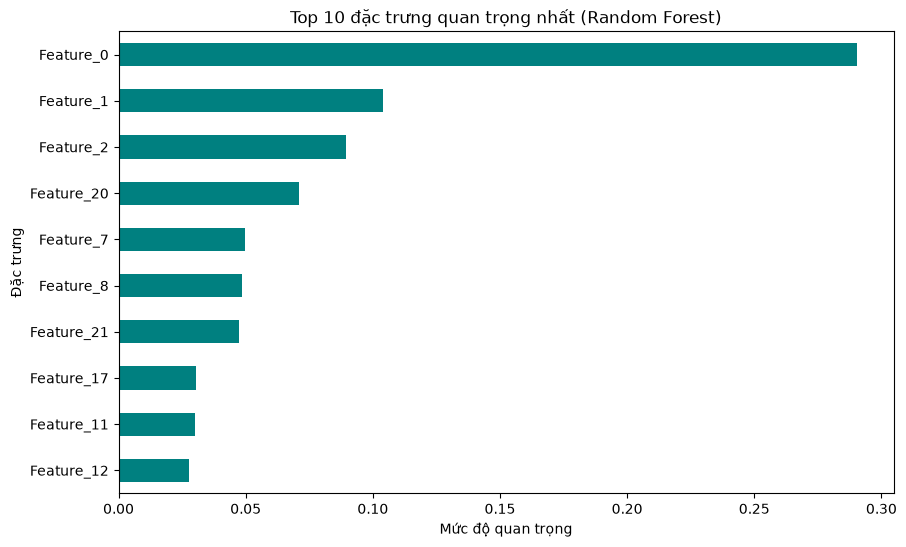

In [7]:
print("============================================================")
print("       3. TRỰC QUAN HÓA CẤU TRÚC VÀ ĐẶC TRƯNG QUAN TRỌNG")
print("============================================================")

# 1. Trực quan hóa Cấu trúc Cây Decision Tree
plt.figure(figsize=(18, 8))
plot_tree(
    trained_models["Decision Tree"],
    feature_names=feature_names,
    class_names=['Bình thường', 'Đột quỵ'],
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title('Cấu trúc Decision Tree (Hiển thị tối đa 3 tầng)')
plt.show()

# 2. Top 10 Đặc trưng quan trọng (Random Forest)
plt.figure(figsize=(10, 6))
rf_imp = pd.Series(trained_models["Random Forest"].feature_importances_, index=feature_names)
rf_imp.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 đặc trưng quan trọng nhất (Random Forest)')
plt.xlabel('Mức độ quan trọng')
plt.ylabel('Đặc trưng')
plt.gca().invert_yaxis()
plt.show()

             4. BẢNG TỔNG HỢP VÀ SO SÁNH HIỆU SUẤT
              Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
Logistic Regression  0.759295   0.142336    0.78  0.240741 0.845206
                SVM  0.807241   0.130653    0.52  0.208835 0.794115
                KNN  0.838552   0.092199    0.26  0.136126 0.627613
      Decision Tree  0.888454   0.100000    0.16  0.123077 0.542963
            XGBoost  0.934442   0.225806    0.14  0.172840 0.787469
      Random Forest  0.936399   0.200000    0.10  0.133333 0.778158


<Figure size 1200x600 with 0 Axes>

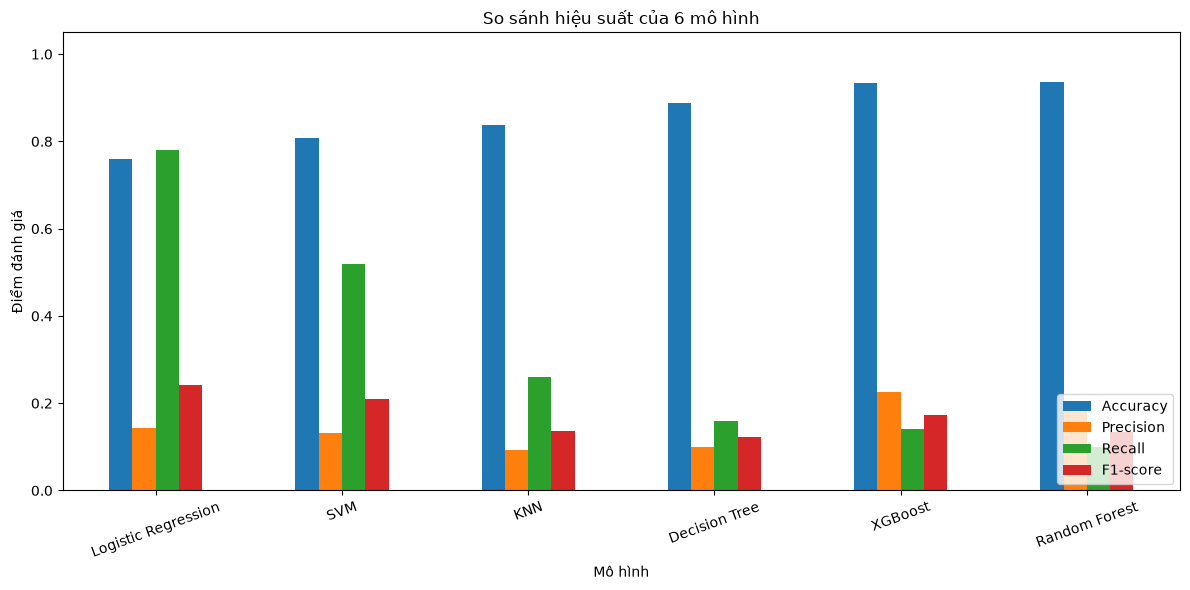

In [8]:
print("============================================================")
print("             4. BẢNG TỔNG HỢP VÀ SO SÁNH HIỆU SUẤT")
print("============================================================")

results = []
for name in models.keys():
    pred = predictions[name]
    prob = probabilities[name]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results).sort_values(by="Recall", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

# Biểu đồ cột so sánh hiệu suất
plt.figure(figsize=(12, 6))
results_plot = results_df.set_index("Model")
results_plot[["Accuracy", "Precision", "Recall", "F1-score"]].plot(kind="bar", figsize=(12, 6))
plt.title("So sánh hiệu suất của 6 mô hình")
plt.xlabel("Mô hình")
plt.ylabel("Điểm đánh giá")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

           5. CONFUSION MATRIX VÀ ĐƯỜNG CONG ROC


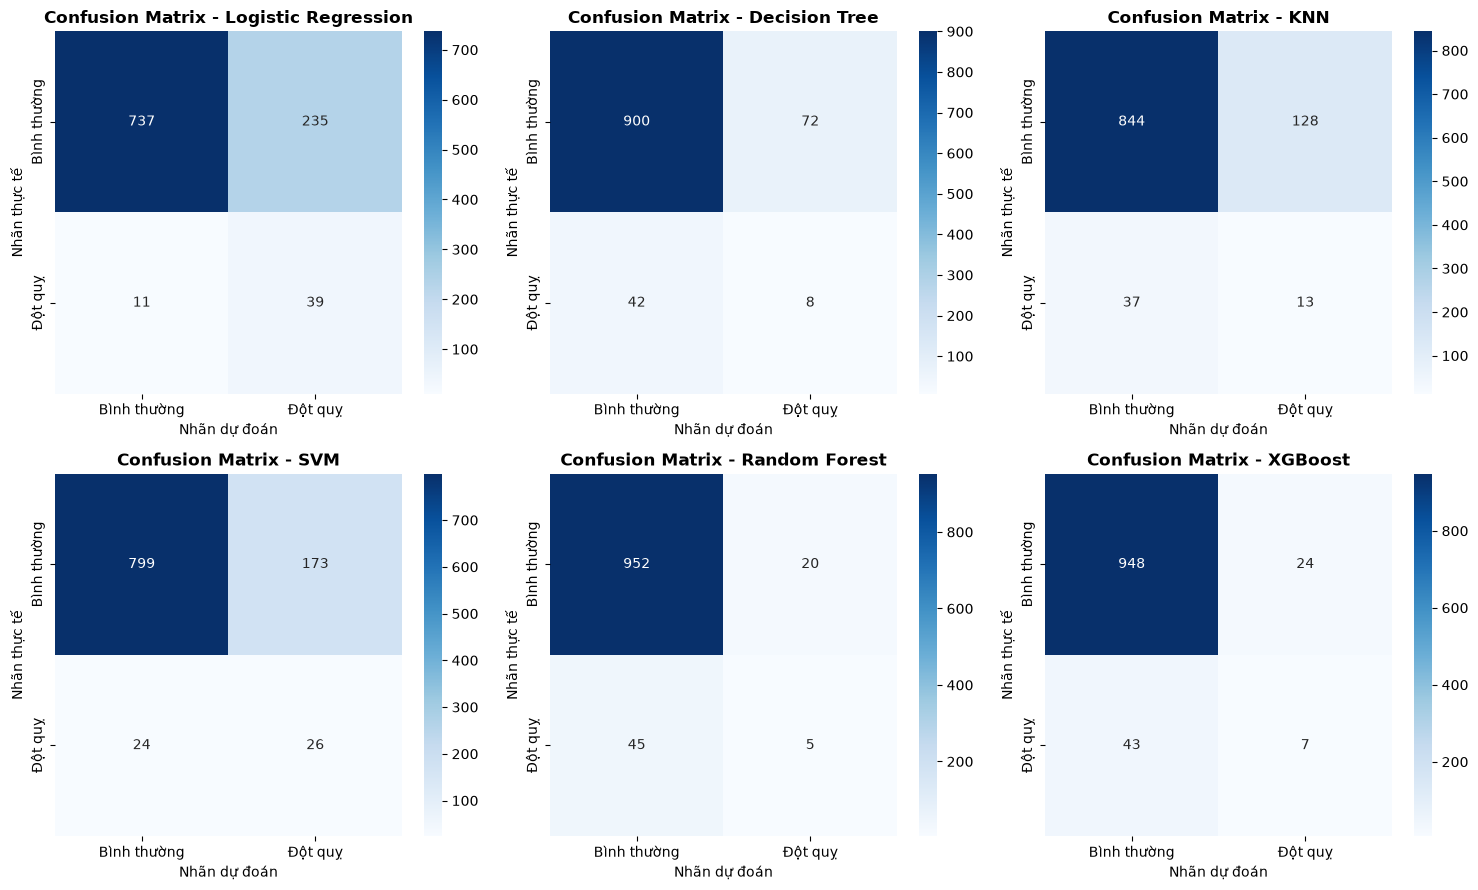

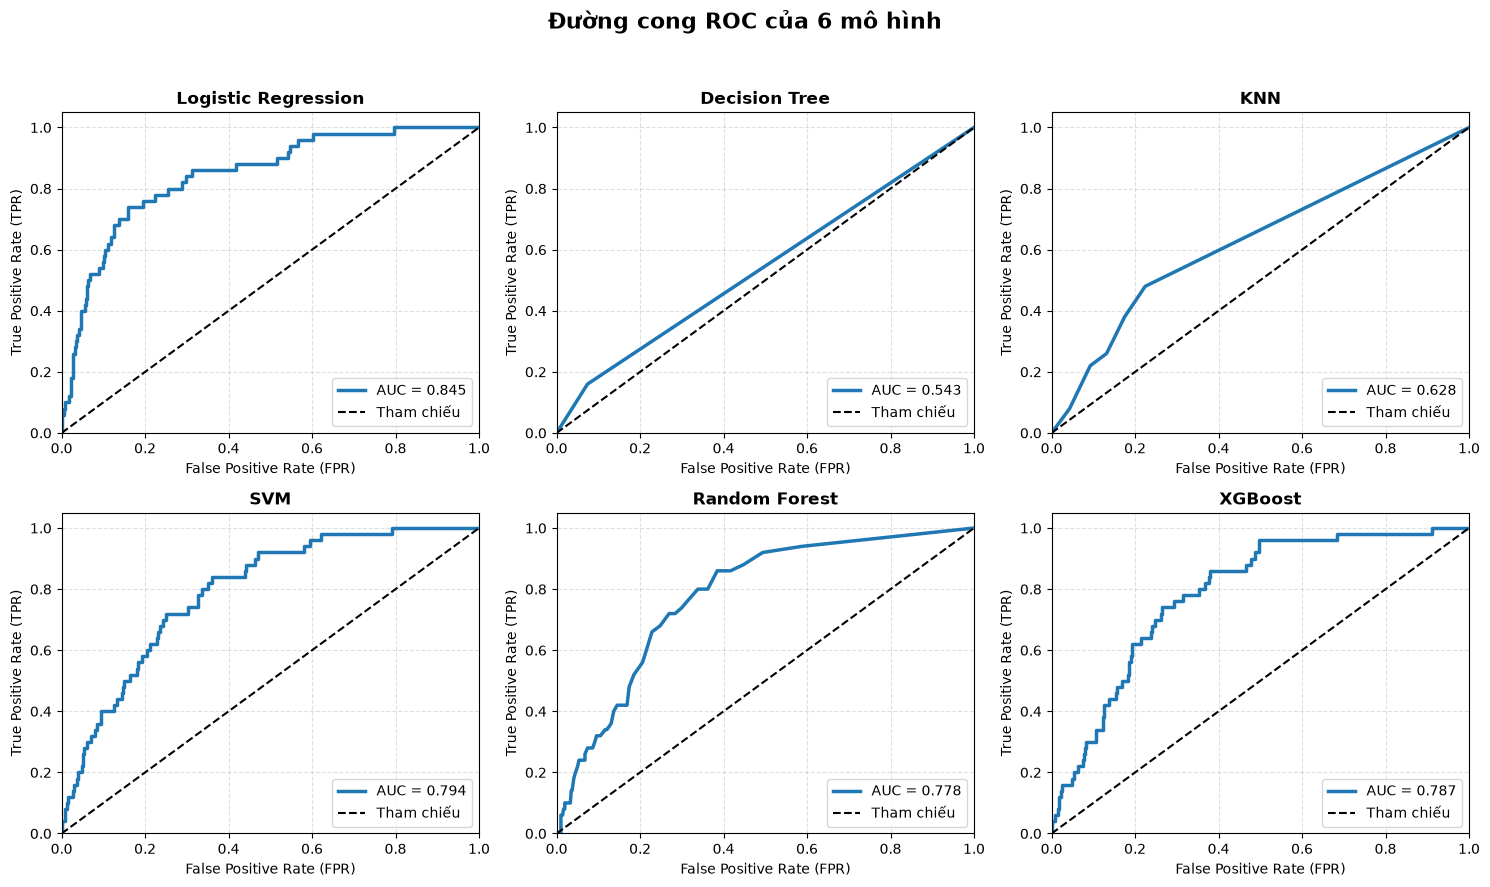

In [9]:
print("============================================================")
print("           5. CONFUSION MATRIX VÀ ĐƯỜNG CONG ROC")
print("============================================================")

# 1. Confusion Matrix
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        xticklabels=["Bình thường", "Đột quỵ"],
        yticklabels=["Bình thường", "Đột quỵ"]
    )
    axes[i].set_title(f"Confusion Matrix - {name}", fontweight="bold")
    axes[i].set_xlabel("Nhãn dự đoán")
    axes[i].set_ylabel("Nhãn thực tế")

plt.tight_layout()
plt.show()

# 2. ROC Curve
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, prob) in enumerate(probabilities.items()):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    
    axes[i].plot(fpr, tpr, linewidth=2.5, label=f"AUC = {auc_val:.3f}")
    axes[i].plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Tham chiếu")
    axes[i].set_title(name, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("False Positive Rate (FPR)")
    axes[i].set_ylabel("True Positive Rate (TPR)")
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1.05)
    axes[i].grid(True, linestyle="--", alpha=0.4)
    axes[i].legend(loc="lower right")

fig.suptitle("Đường cong ROC của 6 mô hình", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [10]:
print("============================================================")
print("  6. DỰ ĐOÁN MẪU THỰC TẾ & XUẤT FILE RESULTS, MODELS")
print("============================================================")

def predict_all_models(sample_data):
    sample_prep = preprocessor.transform(sample_data)
    res_list = []
    for name, model in trained_models.items():
        p = model.predict(sample_prep)[0]
        res_list.append({
            "Model": name,
            "Prediction": p,
            "Result": "Bị đột quỵ" if p == 1 else "Bình thường"
        })
    return pd.DataFrame(res_list)

# Thử dự đoán mẫu đầu tiên trong tập Test
sample = X_test.iloc[[0]]
print("\n--- DỰ ĐOÁN MẪU THỬ BẰNG CẢ 6 MÔ HÌNH ---")
print(predict_all_models(sample).to_string(index=False))

# 1. Lưu bảng kết quả so sánh
results_df.to_csv("../results/cv_results.csv", index=False, encoding="utf-8-sig")

# 2. Đóng gói Mô hình tốt nhất (Chọn theo Recall cao nhất) thành Pipeline hoàn chỉnh
best_model_name = results_df.iloc[0]["Model"]
print(f"\n---> Đang đóng gói mô hình tối ưu ({best_model_name}) vào file .pkl...")

best_pipeline = ImbPipeline([
    ("preprocessor", get_preprocessor()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", get_models(random_state=RANDOM_STATE)[best_model_name])
])
best_pipeline.fit(X_train, y_train)

joblib.dump(best_pipeline, "../models/stroke_pipeline.pkl")

print("\n=== ĐÃ LƯU FILE KẾT QUẢ: results/cv_results.csv ===")
print("=== ĐÃ LƯU FILE MODEL: models/stroke_pipeline.pkl THÀNH CÔNG ===")

  6. DỰ ĐOÁN MẪU THỰC TẾ & XUẤT FILE RESULTS, MODELS

--- DỰ ĐOÁN MẪU THỬ BẰNG CẢ 6 MÔ HÌNH ---
              Model  Prediction      Result
Logistic Regression           0 Bình thường
      Decision Tree           0 Bình thường
                KNN           0 Bình thường
                SVM           0 Bình thường
      Random Forest           0 Bình thường
            XGBoost           0 Bình thường

---> Đang đóng gói mô hình tối ưu (Logistic Regression) vào file .pkl...

=== ĐÃ LƯU FILE KẾT QUẢ: results/cv_results.csv ===
=== ĐÃ LƯU FILE MODEL: models/stroke_pipeline.pkl THÀNH CÔNG ===


In [11]:
import joblib

# Load lại mô hình từ file .pkl
loaded_pipeline = joblib.load("../models/stroke_pipeline.pkl")

# In ra cấu trúc Pipeline đã lưu
print("=== TẢI MÔ HÌNH .PKL THÀNH CÔNG ===")
print(loaded_pipeline)

=== TẢI MÔ HÌNH .PKL THÀNH CÔNG ===
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gende